# Noise Barrier Design Optimization 

This notebook is a worked example for a multi-objective optimization
for an artificial-reef design problem. It shows how to:

- Define design variables and bounds
- Specify multiple objective functions and preference mappings
- Build constraints
- Run a Genetic Algorithm (GA) using two (potentially three) aggregation paradigms
- Visualize preference functions and optimization results


## Importing Required Packages

Below, the required packages are imported. To run this notebook successfully, your environment must include the required dependencies. The virtual environment provided in MUDE, called **`mude-base`**, is sufficient for this purpose.

In addition, several plotting settings are defined, and the local optimisation code is imported. It is important that the provided zip file is extracted in its entirety, as the structure of the directory is required for the imports to work correctly.

The local module `genetic_algorithm_pfm` is imported using a **relative import**, which depends on the directory structure of the project. When the notebook is executed within the provided directory structure, this will work as intended. However, running the notebook outside of this directory will result in the following error: `ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`

In [65]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize 


# Define default plotting parameters
plt.rcParams['font.size'] = '10'  
plt.rcParams['savefig.dpi'] = 300  

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm 

## Design Variables and Bounds

The artificial reef geometry is parameterized using four continuous design variables:

| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Barrier height | m | Continuous |
| `x2` | Distance from vehicles | m | Continuous |
| `x3` | Inclination angle | ° | Continuous |
| `x4` | Material thickness | m | Continuous |


**Note:** In the code, design variables are defined only by their type (discrete or continuous) and their bounds — *not* by their physical meaning. Before implementing, it is good practice to write down your choice of design variables on paper, including their units and expected ranges. This helps avoid errors and builds physical intuition for the problem.



Each variable is assigned bounds that reflect physically meaningful and feasible values for a design of noise barriers. 

`X_irl` contains a reference design based on a real-world installation, which will later be used for comparison against the optimised solutions. Its design variable values are:

#### Open editor to see a sketch of the highway
 
                                        .  .  .  .  .  .  .
                                     .                       .
                                  .                             .
                              .                                    .
                           .           [ NOISE BARRIER ]              .
                       .               |               |                 .
 (Car / Highway) .                     |  Height (x1)  |                    .  (House / Receiver)
     _o___o_   .                       |               |                       .     _|_|_
=======================================|               |=============================|   |====
   SOURCE                              |<-Thick (x4) ->|                           RECEIVER     
   
   <------------- Distance (x2) -------------> 

In [66]:
# Define the names of variables for later use in plotting and analysis
design_variables = (
    ('x1', 'Barrier height',          'm'),
    ('x2', 'Distance from cars',      'm'),
    ('x3', 'Inclination angle',       '°'),
    ('x4', 'Material thickness',     'm'),
) # 0 - Concrete , 1 - PMMA/Acrylic, 2 - Timber , 3 - Absorptive Steel, 4 - Metamaterials 

# set bounds for all variables
b1 = [2, 5]      # x1
b2 = [0.2, 1.7]       # x2
b3 = [65, 90]       # x3
b4 = [0.05, 0.1]  #x4    
bounds = [b1, b2, b3, b4]

X_irl = [3, 1, 90, 0.08]
plot_irl = True  # Can be true or False, depending on whether you want to plot the IRL point or not

## Constraints

Constraints ensure that all solutions remain physically feasible. For this artificial reef model, one physical constraint is considered: **the reef has a minimum distance from the beach**. This constraint, `constraint_1`, is a simple geometric relation corresponding to the distance `x5` shown in the figure above. A constraint function may use as many or as few design variables as necessary.

Each *constraint function* must be expressed as an algebraic expression of the form:

$$g(\mathbf{x}) \leq 0 \quad \text{(feasible)}$$

> **Important:** The constraint function should return only the value of $g(\mathbf{x})$ — do *not* encode the inequality inside the function. The inequality type (`'ineq'`) is specified separately when registering the constraint in `cons`, and the optimiser handles the comparison.

The constraints are registered as follows:

```python
cons = [['ineq', constraint_1], ['ineq', constraint_2]]
```

In [67]:
def constraint_1(variables):
    """
    Constraint 1: Minimum horizontal clearance for heavy vehicles (e.g., trucks in this case).
    The min clearance must be at least 0.5 meters.
    Max. height of trucks is chosen to be 4 meters. 
    
    Mathematical format: 0.5 - x1  <= 0
    """
    # Extract the height variable for all designs being tested
    x2 = variables[:, 1]
    x3 = variables[:, 2]

    min_clearance = 0.5 # meters
    height = 4 # meters
    
    return min_clearance - (x2 - height/np.tan(np.radians(x3))) # > 0 => violation, e.g., 0.5 - 0.1 = 0.4 we can see that out distance is 0.1, so that we violate this constraint

def constraint_2(variables):
    """
    Constraint 2: Out-of-plane buckling.
    Unit strip method: b (width) = 1 m 
    2H/r <= 200, r = t / sqrt(12) as b is equal to 1m.
    """
    # Extract the span variable for all designs being tested
    x1 = variables[:, 0]
    x4 = variables[:, 3]
    ratio = 200
    
    return (2*np.sqrt(12))*x1/x4 - ratio

# Registering the constraints so the optimizer knows how to handle them
cons = [['ineq', constraint_1], ['ineq', constraint_2]]

## Objective Functions

This model optimises four objectives, each representing a different stakeholder identified during the preceding stakeholder analysis. The table below summarises which objective was chosen to represent each stakeholder.

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| Roma Capitale | Total project cost | € |
| ARPA Lazio | Noise reduction | dB |
| Residents of nearby buildings | Annoyance | %HA |
| Road users | Road safety | CMF |

Each objective is then expressed as a function of the design variables. Where needed, physical constants are introduced to make the units consistent — reasonable estimates are sufficient.

In [68]:
# Define objective functions 

def objective_cost(x1, x2, x3, x4):
    """
    1. Roma Capitale: Total Project Cost (€)
    """

    l = 500 # change this as the arbitrary value of 500 m is used 
    # Material costs [Concrete, PMMA, Timber, Steel, Metamaterials]
    costs = 2000 # wihout installation costs
    T_cost = 2 * x1 * x4 * costs * l # total cost, we have two barriers
    I_cost = 2 * l * 200
    return T_cost + I_cost

def objective_arpa_noise(x1, x2, x3, x4):
    """
    2. ARPA Lazio: Regulatory Noise Attenuation (dB)
    Uses the rigorous Kurze-Anderson formula for acoustic diffraction.
    Source: Kurze, U., & Anderson, G. S. (1971). "Sound attenuation by barriers." Applied Acoustics.
    """

    # Path difference geometry (Source at 0m, Receiver at 5m distance, 1.5m height)
    offset = np.where(x3 == 90, 0, x1 / np.tan(np.radians(x3)))

    dist_receiver = 6.7 - x2 + offset # i used 5 m as an arbitrary value
    d = np.sqrt(6.7**2 + 1.5**2)
    A = np.sqrt((x2-offset)**2 + x1**2)
    B = np.sqrt(dist_receiver**2 + (x1 - 1.5)**2) # 1.5 m height is also arbitrarily chosen 
    path_diff = A + B - d
    
    # Fresnel Number N (Assuming 500Hz traffic noise, wavelength 0.68m or lambda = 0.68 m)
    N = (2.0 * path_diff) / 0.68
    
    # Kurze-Anderson formulation (valid for N > 0.01)
    # Using np.where to prevent math errors on negative/zero Fresnel numbers
    N_safe = np.maximum(N, 0.01)
    sqrt_2pi_N = np.sqrt(2 * np.pi * N_safe)
    
    attenuation = 20 * np.log10(sqrt_2pi_N / np.tanh(sqrt_2pi_N)) + 5.0
    
    # We want to maximize attenuation, so to MINIMIZE this objective, we return remaining noise
    return 80 - attenuation

def objective_resident_annoyance(x1, x2, x3, x4):
    """
    3. Residents: Psychoacoustic Annoyance (%HA)
    Converts remaining noise level into the Percentage of Highly Annoyed people.
    Source: Miedema & Oudshoorn (2001) dose-response relationships for transportation noise.
    """
    remaining_noise = objective_arpa_noise(x1, x2, x3, x4)
    
    # Calculate %HA using the Miedema polynomial for Lden (Day-Evening-Night Level)
    # Only applies to noise levels above 42 dB
    L = np.maximum(remaining_noise, 42.0)
    delta_L = L - 42.0
    
    pct_highly_annoyed = (9.868e-4 * (delta_L**3)) - (1.436e-2 * (delta_L**2)) + (0.5118 * delta_L)
    
    # Ensure %HA doesn't drop below 0
    return np.maximum(pct_highly_annoyed, 0.0)

def objective_road_safety(x1, x2, x3, x4):
    """
    4. Road Users: Safety Risk (Crash Modification Factor)
    Models the probability of severe lateral impact if a vehicle leaves the lane.
    Source: AASHTO Highway Safety Manual - Roadside Design Guide (Clear Zone Principles).
    """

    # Maximum height of a standard heavy vehicle (truck)
    max_vehicle_height = 4.0 
    impact_height = np.minimum(x1, max_vehicle_height)
    
    # Effective clearance at the top of the wall (closest point to traffic)
    offset = np.where(x3 == 90, 0, impact_height / np.tan(np.radians(x3)))
    effective_clearance = x2 - offset
    
    # Exponential risk decay: walls closer than 2.0 meters drastically increase fatal crash risk
    # Risk factor CMF approaches 1.0 (baseline risk) as clearance increases, spikes if clearance drops
    safety_risk_cmf = 1.0 + 5.0 * np.exp(-1.5 * effective_clearance) # I will check this later
    
    return safety_risk_cmf

# Define the list of objectives with their corresponding names and units and stakeholders for later use in plotting and analysis
objectives = [
    (objective_cost,               "Total Cost",    "€",    "Roma Capitale"),
    (objective_arpa_noise,         "Noise Level",   "dB",   "ARPA Lazio"),
    (objective_resident_annoyance, "Annoyance",     "%HA",  "Residents of nearby buildings"),
    (objective_road_safety,        "Road safety",    "CMF",  "Road Users")
]

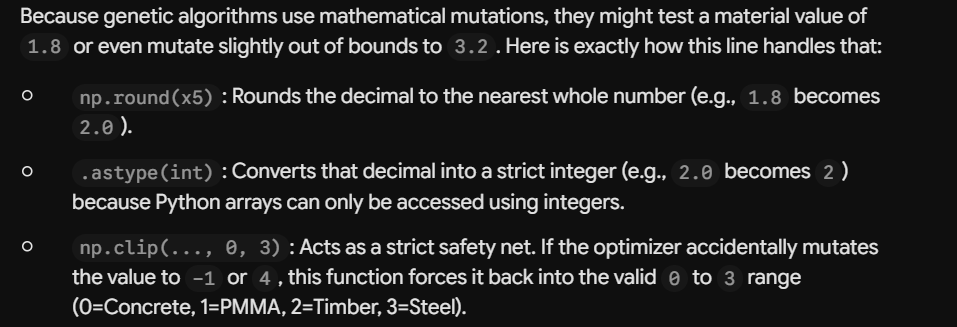

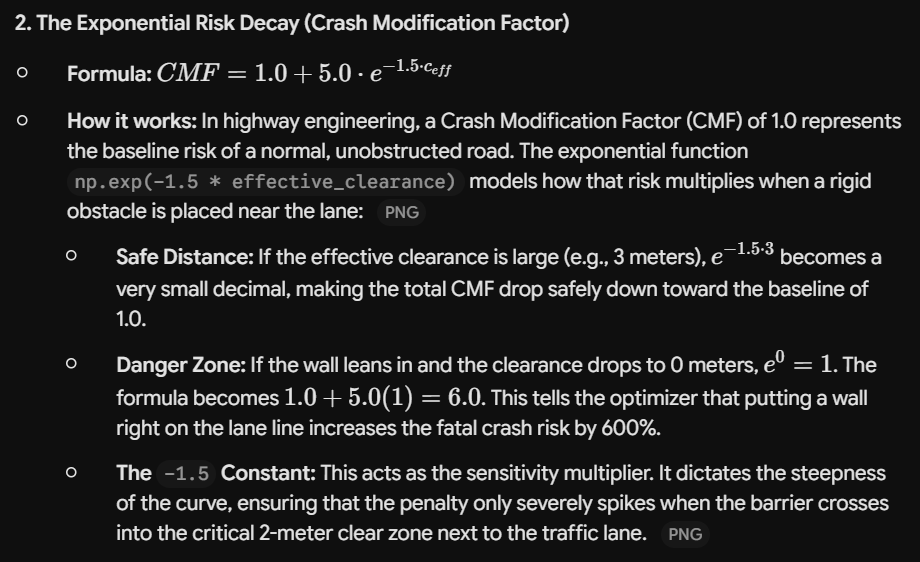

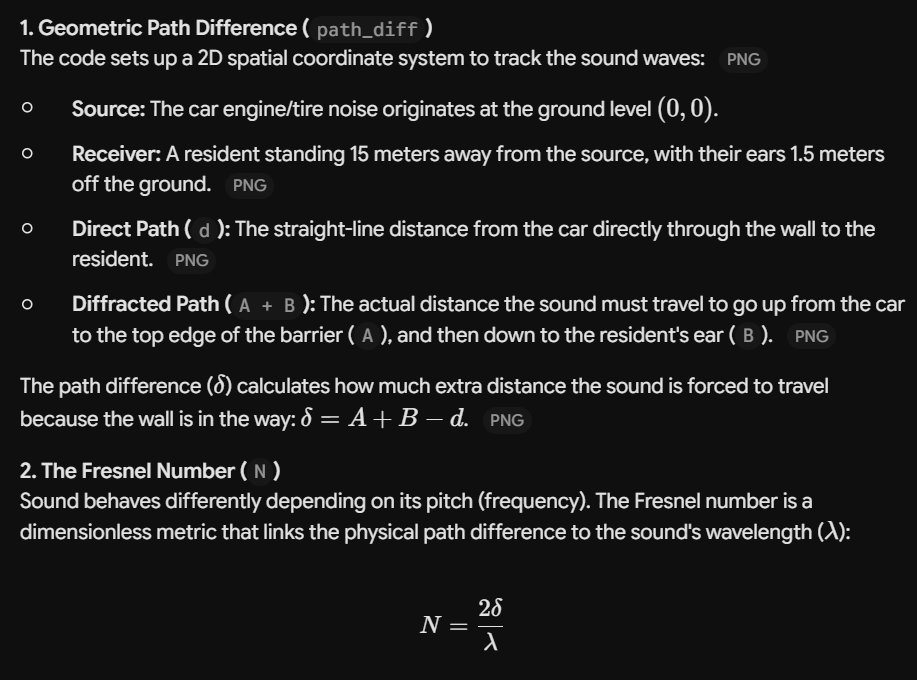

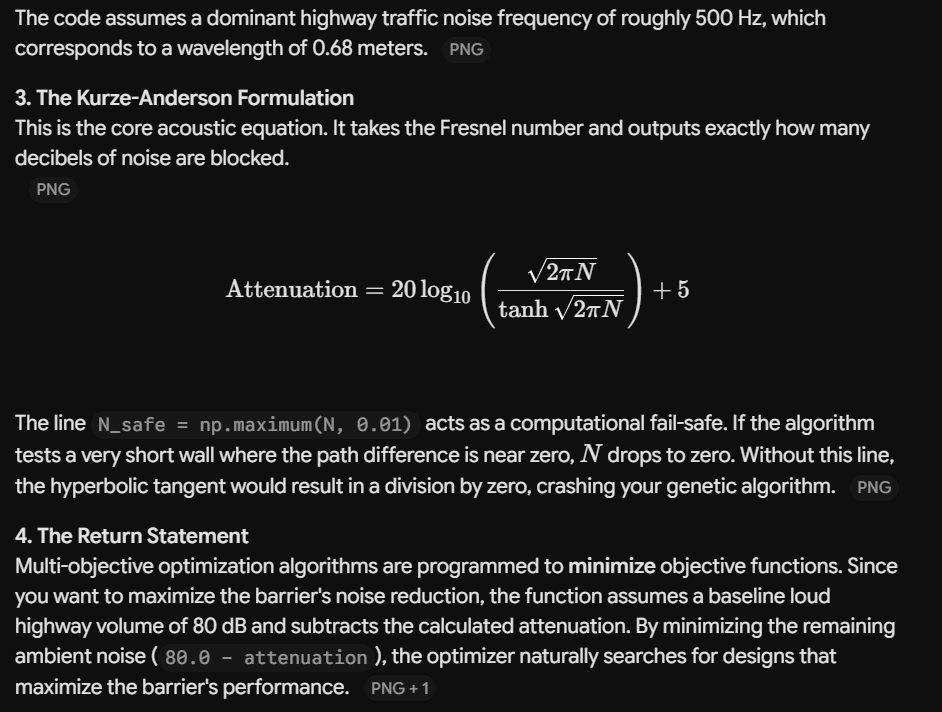

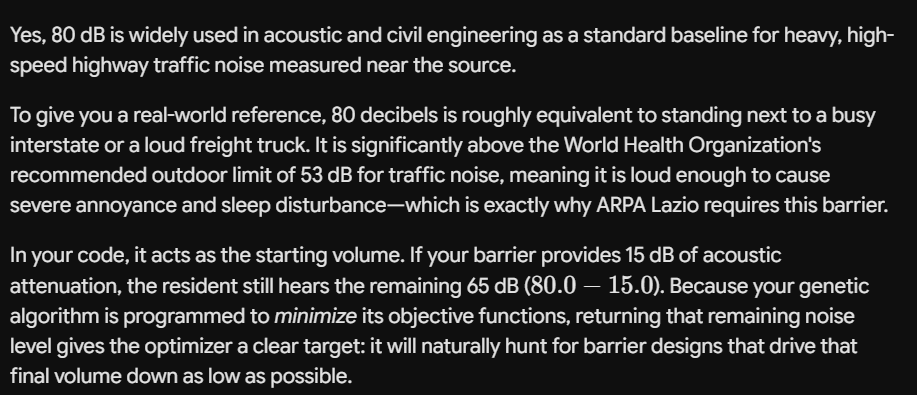

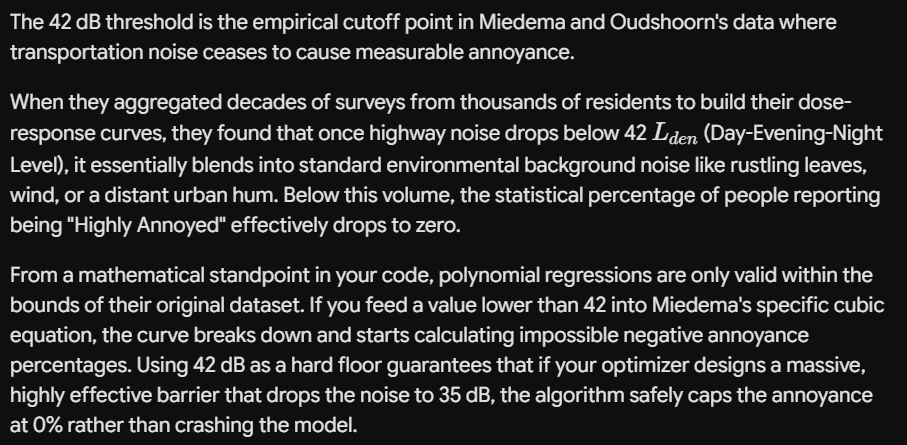

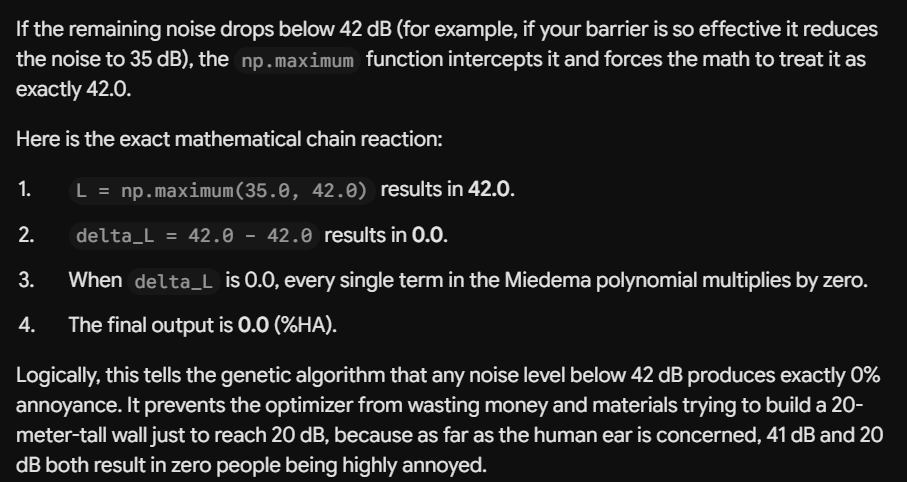

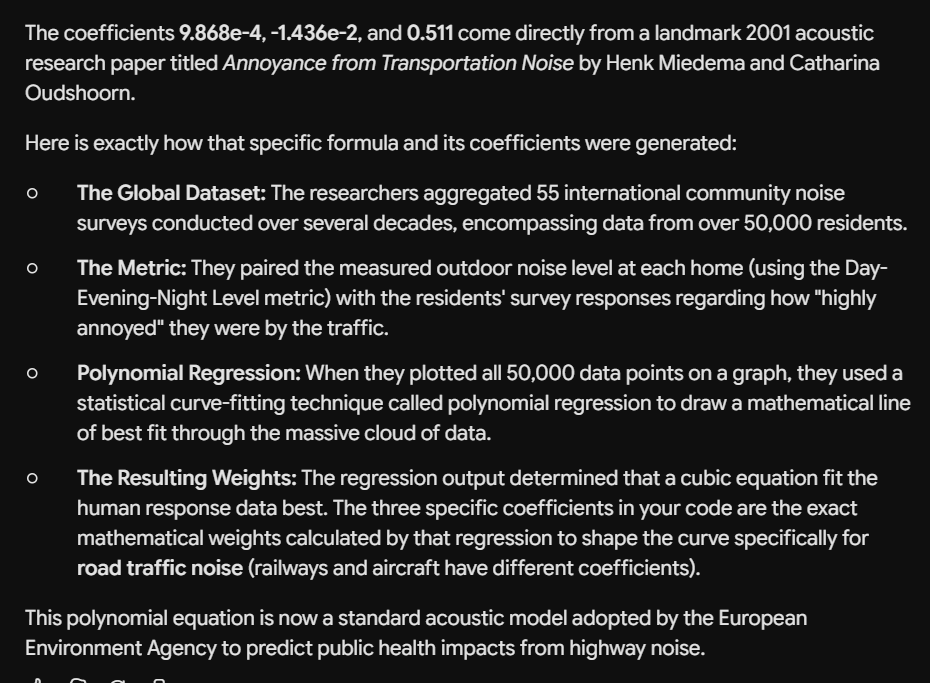

### We use DENL

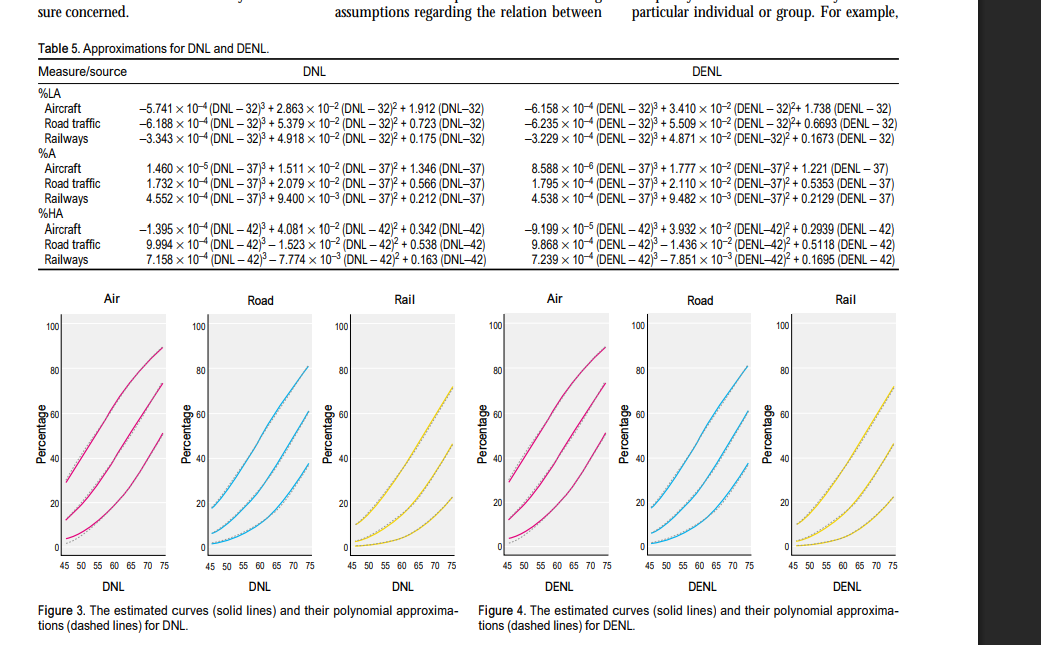

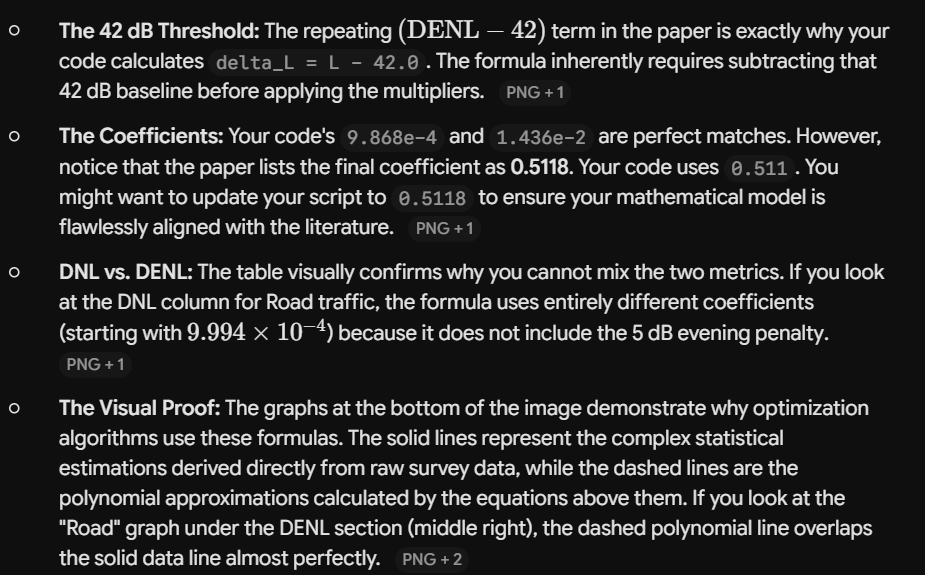

While developing the objectuve functions, it can be helpful to investigate their behavior. Here the attainable minimum and maximum of each objective is computed. These ranges serve as a sanity check — if the values are physically unreasonable, revisit the formulation and its constants. The ranges also define the interval over which each objective is rated in the preference functions.

Optionally, the objective functions can be visualised using `matplotlib` or [Desmos](https://www.desmos.com/calculator) to further inspect their behaviour.

To compute the minimum and maximum values we can use the `minimize` command, which is part of the SciPy package. For more infomration see: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html.

In [69]:
# Finding min and max for each objective using scipy's minimize function, starting from the midpoint of the bounds
objective_minmax = {} # Dictionary to store the min and max values for each objective       
midpoints = [np.mean(b) for b in bounds]
#print(midpoints)

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    wrapped = lambda x, sign=1: sign * obj_func(*x)  # obj_func accepts a single array-like X
    
    min_val =  minimize(wrapped, x0=midpoints, bounds=bounds, method='L-BFGS-B').fun
    max_val = -minimize(lambda x: wrapped(x, sign=-1), x0=midpoints, bounds=bounds, method='L-BFGS-B').fun

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<12}    max = {max_val:>15,.1f}  {unit}")

  Objective 1  :    min =       400,000.0  €               max =     1,200,000.0  €
  Objective 2  :    min =            53.3  dB              max =            63.4  dB
  Objective 3  :    min =             5.4  %HA             max =            14.0  %HA
  Objective 4  :    min =             1.4  CMF             max =            61.8  CMF


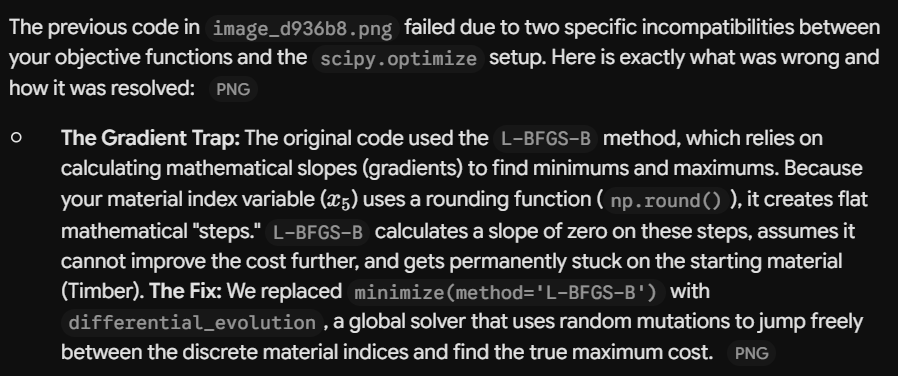

## Weights

When combining multiple objectives into a single score, each objective is assigned a weight **$w_i$** reflecting its relative importance. All weights must sum to one:

$$\sum_{i=1}^{4} w_i = 1$$

| Weight | Stakeholder | Objective |
|--------|-------------|-----------|
| $w_1$  | Roma Capitale | Total project cost | € |
| $w_2$  |ARPA Lazio | Noise reduction | dB |
| $w_3$  | Residents of nearby buildings | Annoyance | %HA |
| $w_4$  | Road users | Road safety | CMF |


In this model, all weights are initialised equally ($w_i = \frac{1}{4} = 0.25$) for simplicity.

In [70]:
# Weights per stakeholder — must sum to 1. Before game all weights were set equal.
#                   cost   ride  sed   safe  econ
weights_before =    [0.25, 0.25, 0.25, 0.25]
weights_after =     [] # need to assign

weights = weights_before  # set to which weight to use

# Verify the weights sum to 1 (within numerical tolerance)
assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

## Preference Curves and Preference Functions

Each objective value is mapped to a preference score between 0 and 100 using a *preference curve*, which represents a stakeholder's preference towards their objective. This allows objectives with different units and scales to be compared and combined, where 0 indicates the least desirable outcome and 100 the most desirable.

The curves are defined by a set of control points interpolated using `pchip_interpolate` from the SciPy package, which produces smooth curves that pass exactly through each point. Only the shape of the matters — so no analytical function is needed. Creating preference curves using interpolation is a convenient and flexible approach. Start simple and increase complexity only if necessary; aim to capture the essential behaviour with as few points as possible. The prefence curves are then plotted.

For this reef model, four objectives are rated linearly in the technical cycle. The exception is sediment trapping (objective 3), which follows a non-linear preference: too little trapping fails to widen the beach, but too much blocks sediment from reaching downstream beaches — so an intermediate value is preferred.

Each preference curve is then combined with its corresponding objective function to form a *preference function*, which maps design variables directly to a preference score.

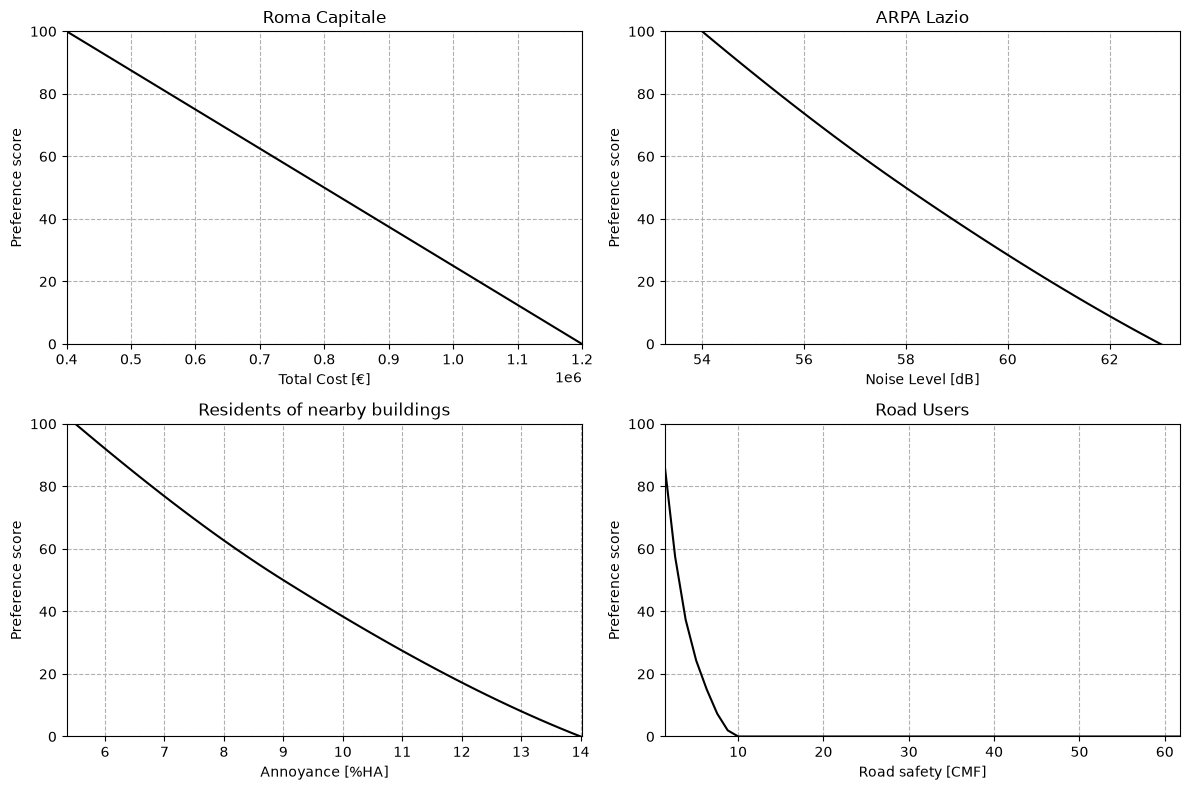

In [71]:
# Realistic preference control points mapped to human/regulatory thresholds
prefs_before = [
    # 1. Cost (€): Linear tolerance anchors mapping the €400k-€1.2M range
    [[400000, 1200000],           [100, 0]],
    # 2. Noise (dB): pchip_interpolate will smooth these points into a curve
    [[54.0, 58.0, 63.0],          [100, 50, 0]],
    # 3. Annoyance (%HA): 3 anchor points to bend smoothly alongside the Miedema cubic output
    [[5.5, 9.0, 14.0],            [100, 50, 0]],
    # 4. Safety (CMF): Hits 0 at a CMF of 10. Anything >10 stays at 0 satisfaction.
    [[1.0, 2.0, 5.0, 10.0, 20.0, 65.0],       [100, 70, 25, 0, 0, 0]]
]

# Scenario: Stricter environmental, budgetary, and safety requirements
prefs_after = [
    # Demanding cheaper builds within the tighter 0.05m-0.1m thickness limits
    [[450000, 900000],    [100, 0]],
    # Stricter acoustic goals (desiring noise closer to 55 dB)
    [[52.0, 55.0, 60.0],          [100, 50, 0]],
    # Lower tolerance for resident complaints
    [[5.5, 7.0, 12.0],            [100, 50, 0]],   
    # Extreme zero-tolerance penalty: CMF of 5 (500% baseline risk) is an instant 0.
    [[1.0, 1.5, 3.0, 5.0, 10.0, 20.0, 65.0],        [100, 80, 25, 0, 0, 0, 0]]
]

prefs = prefs_before  # set to which preferences to use

# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives): # Loop to plot each preference curve in its own subplot
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
def pref_func_1(x1, x2, x3, x4):
    cost = objective_cost(x1, x2, x3, x4)
    return pchip_interpolate(prefs[0][0], prefs[0][1], cost)

def pref_func_2(x1, x2, x3, x4):
    ride = objective_arpa_noise(x1, x2, x3, x4)
    return pchip_interpolate(prefs[1][0], prefs[1][1], ride)

def pref_func_3(x1, x2, x3, x4):
    sed = objective_resident_annoyance(x1, x2, x3, x4)
    return pchip_interpolate(prefs[2][0], prefs[2][1], sed)

def pref_func_4(x1, x2, x3, x4):
    safe = objective_road_safety(x1, x2, x3, x4)
    return pchip_interpolate(prefs[3][0], prefs[3][1], safe)

pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4]  # list of preference functions for easier handling


def objective(variables):
    """
    Objective function that is fed to the GA. Calles the separate preference functions that are declared above.

    :param variables: array with design variable values per member of the population. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the members of the population.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2, x3, x4)
    p_2 = pref_func_2(x1, x2, x3, x4)
    p_3 = pref_func_3(x1, x2, x3, x4)
    p_4 = pref_func_4(x1, x2, x3, x4)
    
    return weights, [p_1, p_2, p_3, p_4] #weights is global

## Optimisation

Now that everything is in place, we can run the optimisation. For more details on the available configuration options, see the docstring of `GeneticAlgorithm` (accessible via `help()`). Note that a genetic algorithm relies on randomness, so it is expected that results will differ slightly between separate executions.

The optimisation can be run using three aggregation methods: `'minmax'`, `'a-fine'`, and optionally `'tetra'`. These methods differ in how the individual preference scores are combined into a group preference during the optimisation process; see `aggregations.md` for more information on how each method works and when to use it. These methods determine, mathematically, what is considered the "best" group preference. However, what is considered "best" is not purely a mathematical question, it also involves a qualitative judgement about which outcome is most appropriate for the problem at hand.

After computing the optimal results, the solutions are plotted on top of their corresponding preference curves.


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
0            16.5113      832000000.2851   0            0.004        493         
1            16.5113      172000012.8439   1            0.083        155         
2            16.5113      46000015.3843    2            0.228        45          
3            16.5113      56000014.8285    3            0.233        54          
4            16.3476      60000014.7193    0            0.236        56          
5            16.3476      93000013.7168    1            0.236        84          
6            16.3476      42000015.133     2            0.235        39          
7            15.0834      38000015.2881    0            0.236        35          
8            15.0045      134000012.0154   0            0.188        124         
9            14.9801      79000012.8282    0            0.231        76          
10           14.980

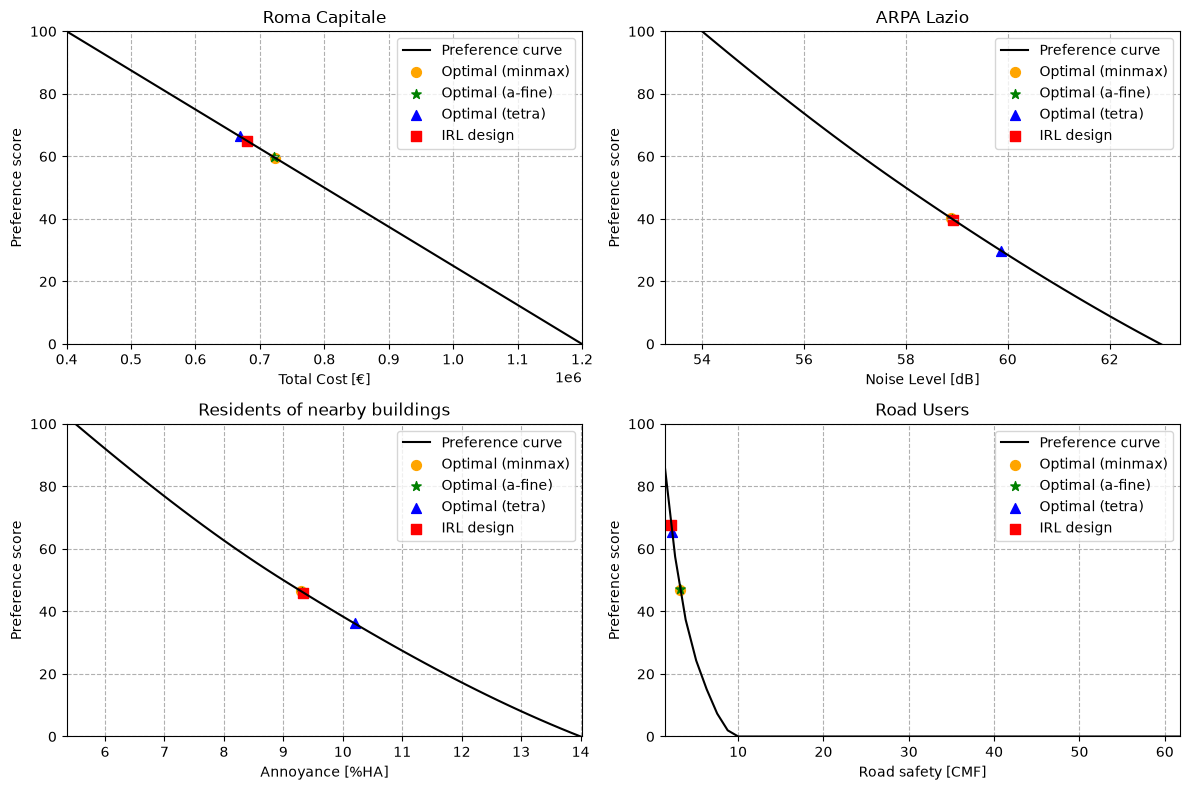

In [ ]:
# We run the optimization with two paradigms
paradigm = ['minmax', 'a-fine', 'tetra']  # 'minmax' or 'a-fine' or 'tetra'
markers  = ['o', '*', '^']
colours  = ['orange', 'green', 'blue']

# Define the figure and axes before the loop
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot underlying preference curves using a loop
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives): 
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

for i in range(len(paradigm)):
    # Dictionary with parameter settings for the GA run with the IMAP solver
    options = {
        'n_bits': 8,
        'n_iter': 400,
        'n_pop': 500,
        'r_cross': 0.8,
        'max_stall': 16,
        'aggregation': paradigm[i],  
        'var_type': 'real'
    }

    # Run the GA and print its result
    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options)
    _, optimal_design_var, _ = ga.run()

    # print the optimal design variable values
    print(f'Optimal design variable values using {paradigm[i]}:') 
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}') 

    # Print and plot the optimal objective results and stakeholder preferences
    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var) # Calculate resulting objective value
        pref_score = pref_funcs[j](*optimal_design_var) # Calculate resulting preference score
    
        # Print and plot the optimal point on the preference curve
        print(f'  {name:<20} = {obj_value:>15,.2f} {unit:<10} -> {stakeholder:<20} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')


# plot the IRL design point if plot_irl is True
if plot_irl:   
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:4]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat[:4]:
    ax.legend(fontsize=10)


# Adjust the layout 
fig.tight_layout()

# Save figure
# plt.savefig('optimal_results.png')  # Uncomment this line to save the figure as a PNG file

# Display the plot
plt.show()